In [1]:
import pandas as pd
import numpy as np
import os
import glob
import statsmodels.api as sm


In [2]:
# path to folder
folder_path = "./Task2Data/*.csv"

files = glob.glob(folder_path)

structural = {}
functional = {}

for file in files:
    name = os.path.basename(file)
    subject = name.split("_")[0]

    mat = pd.read_csv(file, comment='#', header=None).values

    if "WFA" in name:
        structural[subject] = mat
    elif "rsfMRI" in name:
        functional[subject] = mat

print(len(structural), len(functional))

19 19


In [3]:
import os
print(os.getcwd())

C:\Users\agroz\UCL\Comp Model for Bio Imaging\Connectomes project\connectomes-data


In [4]:
def indirect_connectivity(S):

    n = S.shape[0]
    T = np.zeros_like(S)

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            vals = []

            for k in range(n):

                if S[i,k] > 0 and S[k,j] > 0:
                    vals.append(min(S[i,k], S[k,j]))

            if vals:
                T[i,j] = max(vals)

    return T

In [5]:
T_matrices = {}

for subject in structural:

    S = structural[subject]
    T = indirect_connectivity(S)

    T_matrices[subject] = T

T_matrices


{'32': array([[0.        , 0.42255735, 0.40971658, ..., 0.        , 0.        ,
         0.42255735],
        [0.42255735, 0.        , 0.49604311, ..., 0.32162235, 0.46948489,
         0.45943316],
        [0.40971658, 0.49604311, 0.        , ..., 0.34516057, 0.46948489,
         0.43447875],
        ...,
        [0.        , 0.32162235, 0.34516057, ..., 0.        , 0.34516057,
         0.34516057],
        [0.        , 0.46948489, 0.46948489, ..., 0.34516057, 0.        ,
         0.42188022],
        [0.42255735, 0.45943316, 0.43447875, ..., 0.34516057, 0.42188022,
         0.        ]], shape=(68, 68)),
 '33': array([[0.        , 0.41149768, 0.43011361, ..., 0.        , 0.        ,
         0.43516083],
        [0.41149768, 0.        , 0.48380023, ..., 0.28125498, 0.49564331,
         0.44916189],
        [0.43011361, 0.48380023, 0.        , ..., 0.28125498, 0.48380023,
         0.48352925],
        ...,
        [0.        , 0.28125498, 0.28125498, ..., 0.        , 0.28125498,
      

In [6]:
def three_step_connectivity(S):

    n = S.shape[0]
    M = np.zeros_like(S)

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            vals = []

            for k in range(n):
                for f in range(n):

                    if S[i,k] > 0 and S[k,f] > 0 and S[f,j] > 0:
                        vals.append(min(S[i,k], S[k,f], S[f,j]))

            if vals:
                M[i,j] = max(vals)

    return M

In [7]:
M_matrices = {}

for subject in structural:

    S = structural[subject]
    M = three_step_connectivity(S)

    M_matrices[subject] = M

M_matrices

{'32': array([[0.        , 0.42255735, 0.42255735, ..., 0.34516057, 0.42255735,
         0.42255735],
        [0.42255735, 0.        , 0.49604311, ..., 0.34516057, 0.46948489,
         0.46882067],
        [0.42255735, 0.49604311, 0.        , ..., 0.34516057, 0.45287165,
         0.46176718],
        ...,
        [0.34516057, 0.34516057, 0.34516057, ..., 0.        , 0.34516057,
         0.34516057],
        [0.42255735, 0.46948489, 0.45287165, ..., 0.34516057, 0.        ,
         0.46176718],
        [0.42255735, 0.46882067, 0.46176718, ..., 0.34516057, 0.46176718,
         0.        ]], shape=(68, 68)),
 '33': array([[0.        , 0.43516083, 0.43516083, ..., 0.28125498, 0.43516083,
         0.43516083],
        [0.43516083, 0.        , 0.4822579 , ..., 0.28125498, 0.4822579 ,
         0.49227009],
        [0.43516083, 0.4822579 , 0.        , ..., 0.28125498, 0.47228946,
         0.48380023],
        ...,
        [0.28125498, 0.28125498, 0.28125498, ..., 0.        , 0.28125498,
      

In [8]:
subjects = list(structural.keys())
# Get the number of regions from one of the structural matrices
num_regions = structural[subjects[0]].shape[0]

In [9]:
from scipy.sparse.csgraph import shortest_path
import numpy as np

E_matrices = {}

for s in subjects:
    S = structural[s].copy().astype(float)

    # convert weights to lengths
    D = np.full(S.shape, np.inf)
    mask = S > 0
    D[mask] = 1.0 / S[mask]
    np.fill_diagonal(D, 0)

    # shortest path lengths
    L = shortest_path(D, directed=False, unweighted=False)

    # efficiency = 1 / L
    E = np.zeros_like(L)
    valid = np.isfinite(L) & (L > 0)
    E[valid] = 1.0 / L[valid]

    E_matrices[s] = E

## Refit All Models with AIC/BIC


In [10]:
def get_features(structural_data, indirect_structural_data, third_step_data, subjects, region_i, region_j,
                 include_s, include_t, include_s2, include_t2, include_comm=False):
    exog = []

    if include_s:
        s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
        exog.append(s_ij)

    if include_t:
        t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
        exog.append(t_ij)

    if include_s2:
        if not include_s:
            s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
        exog.append(s_ij ** 2)

    if include_t2:
        if not include_t:
            t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
        exog.append(t_ij ** 2)

    if include_comm:
        s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
        t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
        m_ij = np.array([third_step_data[s][region_i, region_j] for s in subjects])

        c_ij = s_ij + 0.5 * t_ij + (1/6) * m_ij
        exog.append(c_ij)

    return exog

def fit_generalized_model(functional_data, structural_data, indirect_structural_data, third_step_data,
                          subject_list, region_i, region_j,
                          include_s, include_t, include_s2, include_t2, include_comm=False):
    """
    Fits a generalized linear model for functional connectivity.
    """

    f_ij = np.array([functional_data[s][region_i, region_j] for s in subject_list])

    exog_vars = get_features(
        structural_data, indirect_structural_data, third_step_data, subject_list,
        region_i, region_j,
        include_s, include_t, include_s2, include_t2, include_comm
    )

    if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
        return None

    X = np.column_stack(exog_vars)
    X = sm.add_constant(X)

    model = sm.OLS(f_ij, X).fit()
    return model

In [11]:
model1_results = {}
model2_results = {}
model3_results = {}
model4_results = {}
model5_results = {}
model6_results = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        res1 = fit_generalized_model(functional, structural, T_matrices, M_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=False, include_t2=False, include_comm=False)
        if res1 is not None:
            model1_results[(i, j)] = res1

        res2 = fit_generalized_model(functional, structural, T_matrices, M_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=True, include_t2=False, include_comm=False)
        if res2 is not None:
            model2_results[(i, j)] = res2

        res3 = fit_generalized_model(functional, structural, T_matrices, M_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=False, include_comm=False)
        if res3 is not None:
            model3_results[(i, j)] = res3

        res4 = fit_generalized_model(functional, structural, T_matrices, M_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=True, include_comm=False)
        if res4 is not None:
            model4_results[(i, j)] = res4

        res5 = fit_generalized_model(functional, structural, T_matrices, M_matrices, subjects, i, j,
                                     include_s=True, include_t=True, include_s2=False, include_t2=False, include_comm=False)
        if res5 is not None:
            model5_results[(i, j)] = res5

        # Model 6: communicability-inspired approximation
        res6 = fit_generalized_model(functional, structural, T_matrices, M_matrices, subjects, i, j,
                                     include_s=False, include_t=False, include_s2=False, include_t2=False, include_comm=True)
        if res6 is not None:
            model6_results[(i, j)] = res6

print(f"Refitted models for {num_regions} regions.")
print(f"Example entry (0,2) Model 1 AIC: {model1_results[(0,2)].aic}")
print(f"Example entry (0,2) Model 6 AIC: {model6_results[(0,2)].aic}")

Refitted models for 68 regions.
Example entry (0,2) Model 1 AIC: -52.19583544402781
Example entry (0,2) Model 6 AIC: -52.488104985312134


## Implement Leave-One-Out Cross-Validation

In [12]:
def perform_loocv(functional_data, structural_data, indirect_structural_data, third_step_data,
                  subject_list, region_i, region_j,
                  include_s, include_t, include_s2, include_t2, include_comm=False):
    """
    Evaluates model predictive performance using Leave-One-Out Cross-Validation (LOOCV).
    Returns the total Sum of Squared Errors (SSE) across all subjects.
    """
    total_sse = 0
    num_subjects = len(subject_list)

    for idx in range(num_subjects):
        test_subject = subject_list[idx]
        train_subjects = [s for i, s in enumerate(subject_list) if i != idx]

        model = fit_generalized_model(
            functional_data, structural_data, indirect_structural_data, third_step_data,
            train_subjects, region_i, region_j,
            include_s, include_t, include_s2, include_t2, include_comm
        )
        if model is None:
            continue

        y_test = functional_data[test_subject][region_i, region_j]

        X_test_raw = get_features(
            structural_data, indirect_structural_data, third_step_data,
            [test_subject], region_i, region_j,
            include_s, include_t, include_s2, include_t2, include_comm
        )

        if not X_test_raw:
            continue

        X_test_raw = np.column_stack(X_test_raw)
        X_test = sm.add_constant(X_test_raw, has_constant='add')

        prediction = model.predict(X_test)[0]
        squared_error = (y_test - prediction) ** 2
        total_sse += squared_error

    return total_sse

## Calculate SSE for All Models

### Subtask:
Iterate through all brain region pairs and compute the total Sum of Squared Errors (SSE) for each of the five models using the perform_loocv function.


**Reasoning**:
I will initialize the SSE dictionaries and iterate through all brain region pairs to compute the LOOCV SSE for all five models using the previously defined perform_loocv function.



In [13]:
sse_model1 = {}
sse_model2 = {}
sse_model3 = {}
sse_model4 = {}
sse_model5 = {}
sse_model6 = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        sse1 = perform_loocv(functional, structural, T_matrices, M_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=False, include_t2=False, include_comm=False)
        if sse1 is not None:
            sse_model1[(i, j)] = sse1

        sse2 = perform_loocv(functional, structural, T_matrices, M_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=True, include_t2=False, include_comm=False)
        if sse2 is not None:
            sse_model2[(i, j)] = sse2

        sse3 = perform_loocv(functional, structural, T_matrices, M_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=False, include_comm=False)
        if sse3 is not None:
            sse_model3[(i, j)] = sse3

        sse4 = perform_loocv(functional, structural, T_matrices, M_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=True, include_comm=False)
        if sse4 is not None:
            sse_model4[(i, j)] = sse4

        sse5 = perform_loocv(functional, structural, T_matrices, M_matrices, subjects, i, j,
                             include_s=True, include_t=True, include_s2=False, include_t2=False, include_comm=False)
        if sse5 is not None:
            sse_model5[(i, j)] = sse5

        # Model 6: communicability-inspired approximation
        sse6 = perform_loocv(functional, structural, T_matrices, M_matrices, subjects, i, j,
                             include_s=False, include_t=False, include_s2=False, include_t2=False, include_comm=True)
        if sse6 is not None:
            sse_model6[(i, j)] = sse6

print(f"LOOCV SSE calculation completed for {num_regions} regions.")

LOOCV SSE calculation completed for 68 regions.


## Plot Model Comparison


C:\Users\agroz\AppData\Local\Temp\ipykernel_23060\844613857.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0], palette='Set2')
C:\Users\agroz\AppData\Local\Temp\ipykernel_23060\844613857.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[1], palette='Set2')
C:\Users\agroz\AppData\Local\Temp\ipykernel_23060\844613857.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[2], palette='Set2')


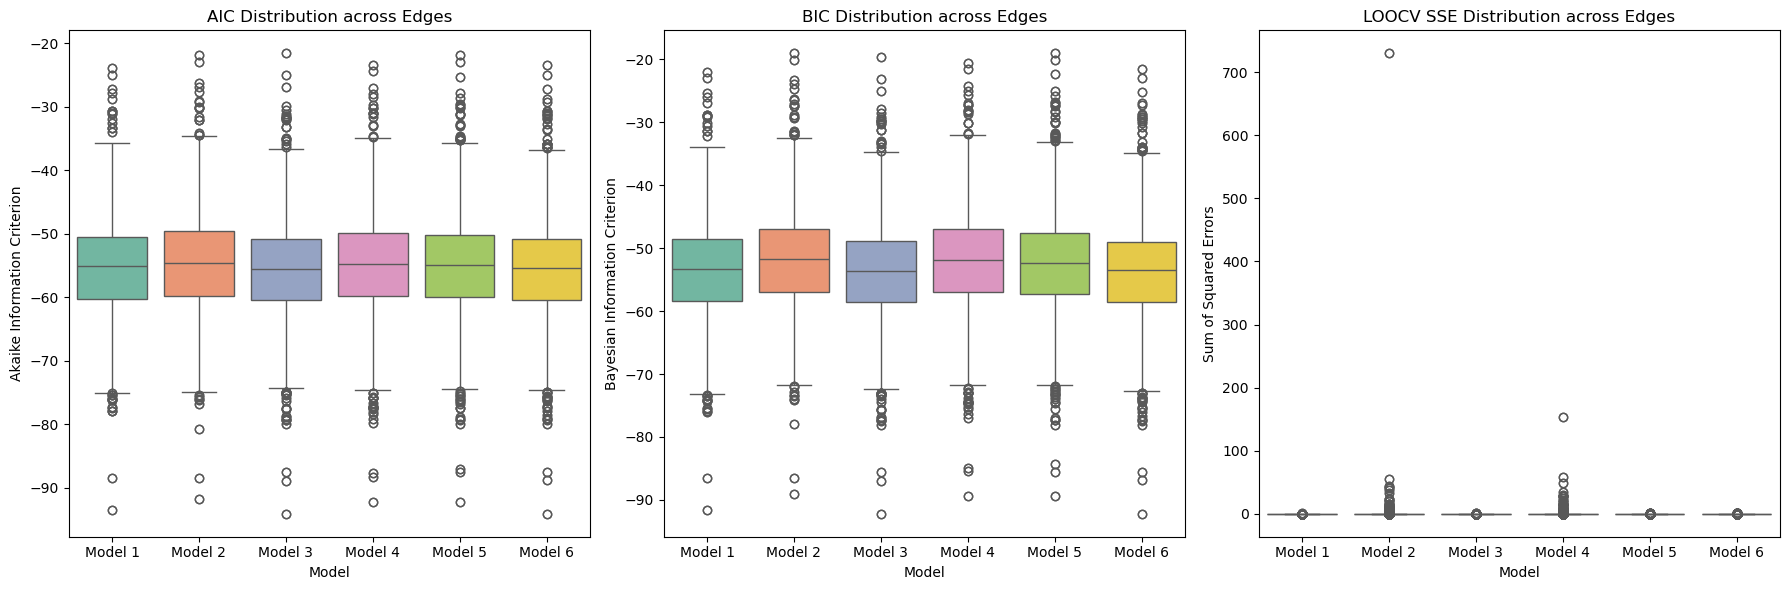

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data lists for AIC, BIC, and SSE
data = []

model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5', 'Model 6']
res_dicts = [model1_results, model2_results, model3_results, model4_results, model5_results, model6_results]
sse_dicts = [sse_model1, sse_model2, sse_model3, sse_model4, sse_model5, sse_model6]

for idx, m_name in enumerate(model_names):
    current_res = res_dicts[idx]
    current_sse = sse_dicts[idx]

    # Get common keys (edges) present in both results and SSE for consistency
    common_keys = set(current_res.keys()) & set(current_sse.keys())

    for key in common_keys:
        data.append({
            'Model': m_name,
            'AIC': current_res[key].aic,
            'BIC': current_res[key].bic,
            'SSE': current_sse[key]
        })

# Create DataFrame
comparison_df = pd.DataFrame(data)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# AIC Box Plot
sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0], palette='Set2')
axes[0].set_title('AIC Distribution across Edges')
axes[0].set_ylabel('Akaike Information Criterion')

# BIC Box Plot
sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[1], palette='Set2')
axes[1].set_title('BIC Distribution across Edges')
axes[1].set_ylabel('Bayesian Information Criterion')

# SSE Box Plot
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[2], palette='Set2')
axes[2].set_title('LOOCV SSE Distribution across Edges')
axes[2].set_ylabel('Sum of Squared Errors')

plt.tight_layout()
plt.show()

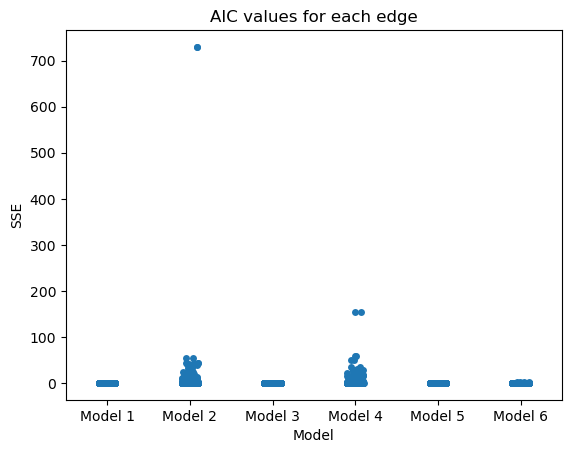

In [15]:
sns.stripplot(data=comparison_df, x="Model", y="SSE", jitter=True)
plt.title("AIC values for each edge")
plt.show()

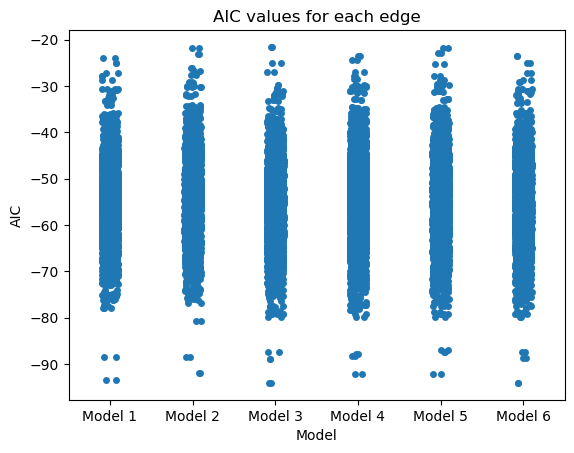

In [16]:
sns.stripplot(data=comparison_df, x="Model", y="AIC", jitter=True)
plt.title("AIC values for each edge")
plt.show()

C:\Users\agroz\AppData\Local\Temp\ipykernel_23060\2192705924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="Model", y="AIC", ax=axes[0], palette="Set2")
C:\Users\agroz\AppData\Local\Temp\ipykernel_23060\2192705924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="Model", y="BIC", ax=axes[1], palette="Set2")


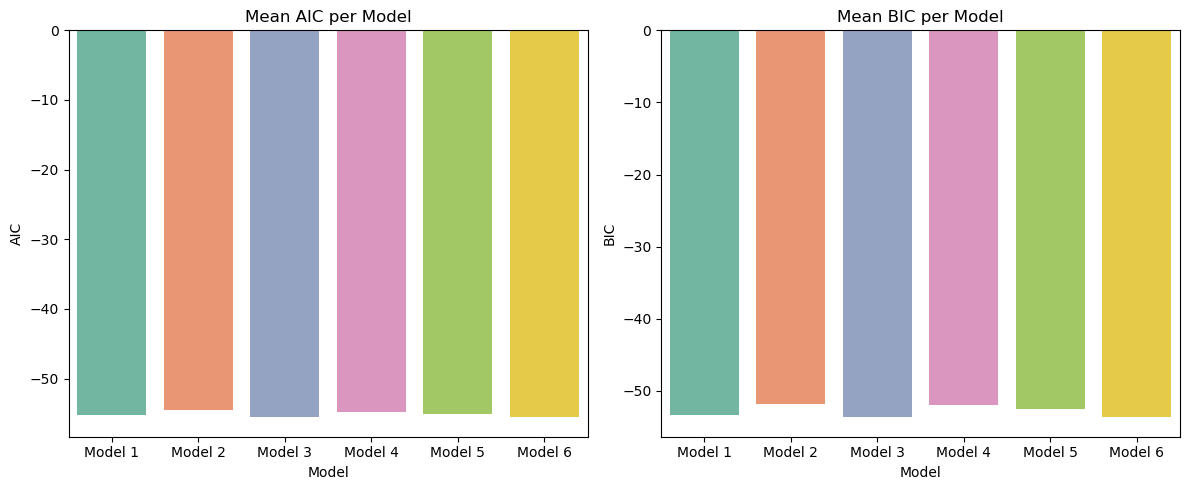

In [17]:
summary = comparison_df.groupby("Model")[["AIC","BIC","SSE"]].mean().reset_index()

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=summary, x="Model", y="AIC", ax=axes[0], palette="Set2")
axes[0].set_title("Mean AIC per Model")

sns.barplot(data=summary, x="Model", y="BIC", ax=axes[1], palette="Set2")
axes[1].set_title("Mean BIC per Model")

plt.tight_layout()
plt.show()

In [18]:
summary_table = comparison_df.groupby("Model").agg(
    Mean_AIC=("AIC", "mean"),
    SD_AIC=("AIC", "std"),
    Mean_BIC=("BIC", "mean"),
    SD_BIC=("BIC", "std"),
    Mean_SSE=("SSE", "mean"),
    SD_SSE=("SSE", "std")
)

summary_table.round(3)

,Mean_AIC,SD_AIC,Mean_BIC,SD_BIC,Mean_SSE,SD_SSE
Model,,,,,,
Model 1,-55.248,7.884,-53.359,7.884,0.069,0.036
Model 2,-54.585,8.042,-51.874,8.064,0.940,18.951
Model 3,-55.581,7.763,-53.692,7.763,0.068,0.035
Model 4,-54.822,7.923,-51.991,7.926,0.397,4.046
Model 5,-55.060,7.893,-52.538,7.948,0.072,0.040
Model 6,-55.536,7.739,-53.647,7.739,0.075,0.075


In [24]:
summary_table = comparison_df.groupby("Model").agg(
    Mean_AIC=("AIC", "mean"),
    SD_AIC=("AIC", "std"),
    Mean_BIC=("BIC", "mean"),
    SD_BIC=("BIC", "std"),
    Mean_SSE=("SSE", "mean"),
    SD_SSE=("SSE", "std")
)

# sort by best predictive performance (lowest SSE)
summary_table_sorted = summary_table.sort_values("Mean_AIC")

summary_table_sorted.round(3)

,Mean_AIC,SD_AIC,Mean_BIC,SD_BIC,Mean_SSE,SD_SSE
Model,,,,,,
Model 3,-55.581,7.763,-53.692,7.763,0.068,0.035
Model 6,-55.536,7.739,-53.647,7.739,0.075,0.075
Model 1,-55.248,7.884,-53.359,7.884,0.069,0.036
Model 5,-55.060,7.893,-52.538,7.948,0.072,0.040
Model 4,-54.822,7.923,-51.991,7.926,0.397,4.046
Model 2,-54.585,8.042,-51.874,8.064,0.940,18.951


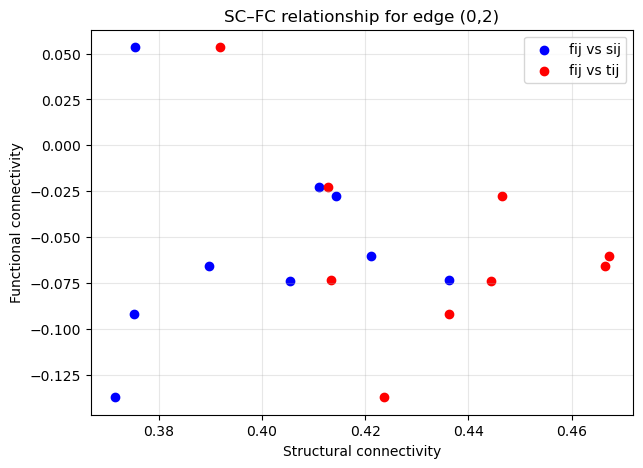

In [20]:
region_i = 0
region_j = 2

f_vals = np.array([functional[s][region_i, region_j] for s in subjects])
s_vals = np.array([structural[s][region_i, region_j] for s in subjects])
t_vals = np.array([T_matrices[s][region_i, region_j] for s in subjects])

# remove cases where structural connectivity is zero
mask = (s_vals > 0)

f_vals = f_vals[mask]
s_vals = s_vals[mask]
t_vals = t_vals[mask]

plt.figure(figsize=(7,5))

plt.scatter(s_vals, f_vals, color="blue", label="fij vs sij")
plt.scatter(t_vals, f_vals, color="red", label="fij vs tij")

plt.xlabel("Structural connectivity")
plt.ylabel("Functional connectivity")
plt.title(f"SC–FC relationship for edge ({region_i},{region_j})")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


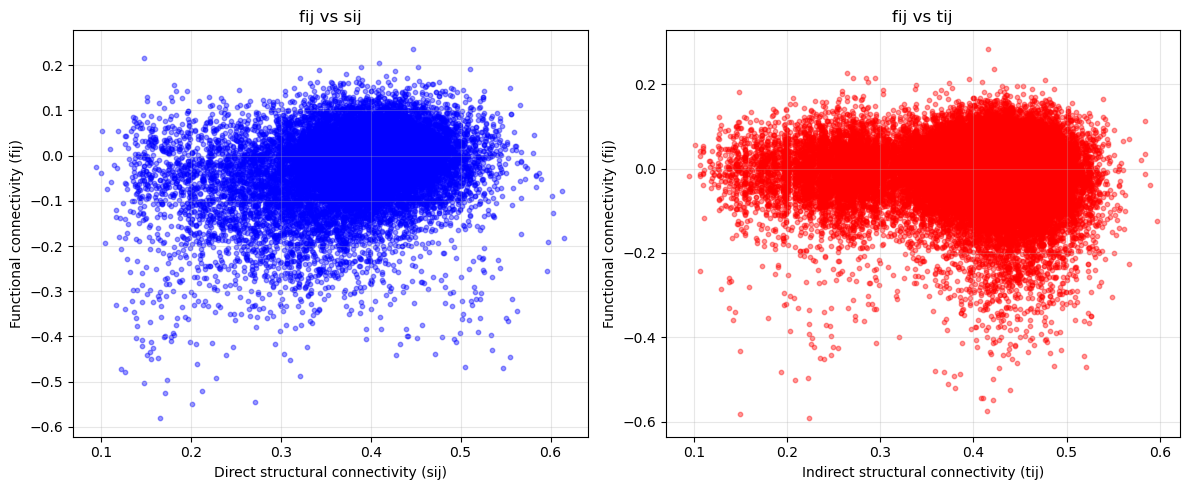

In [21]:
import matplotlib.pyplot as plt
import numpy as np

all_f_s = []
all_s = []

all_f_t = []
all_t = []

for s in subjects:
    F = functional[s]
    S = structural[s]
    T = T_matrices[s]

    for i in range(num_regions):
        for j in range(i+1, num_regions):
            fij = F[i, j]
            sij = S[i, j]
            tij = T[i, j]

            if sij > 0:
                all_f_s.append(fij)
                all_s.append(sij)

            if tij > 0:
                all_f_t.append(fij)
                all_t.append(tij)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(all_s, all_f_s, alpha=0.4, s=10, color="blue")
axes[0].set_title("fij vs sij")
axes[0].set_xlabel("Direct structural connectivity (sij)")
axes[0].set_ylabel("Functional connectivity (fij)")
axes[0].grid(alpha=0.3)

axes[1].scatter(all_t, all_f_t, alpha=0.4, s=10, color="red")
axes[1].set_title("fij vs tij")
axes[1].set_xlabel("Indirect structural connectivity (tij)")
axes[1].set_ylabel("Functional connectivity (fij)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()